A continuación se presentan algunos test de tiempo para el algoritmo `get_energy` en el contexto del modelo de Ising.

En el modelo de Ising bidimensional consideramos un sistema con una grilla (o lattice) con $N$ sitios. Si consideramos la grilla como una matriz cuadrada de $n\times n=N$ podríamos tener un sistema como sigue.

### El sistema del modelo de Ising como un arreglo bidimensional

In [54]:
using Random

n = 100

init_random = rand(n, n)
lattice_rand = zeros(Int, n, n)
lattice_rand[init_random .>=0.5] .= 1
lattice_rand[init_random .< 0.5] .= -1
lattice_rand

100×100 Matrix{Int64}:
 -1  -1   1   1  -1  -1  -1  -1   1  …  -1   1  -1   1  -1   1   1   1   1
 -1   1  -1  -1  -1  -1   1  -1   1     -1  -1   1   1   1   1  -1  -1   1
  1  -1  -1  -1   1  -1   1   1   1      1  -1  -1  -1   1   1  -1  -1  -1
  1   1   1   1   1  -1  -1  -1   1      1  -1   1  -1   1   1  -1  -1  -1
  1  -1  -1  -1  -1  -1   1   1  -1      1   1  -1   1   1  -1  -1  -1  -1
  1  -1   1  -1   1   1   1   1  -1  …  -1   1   1   1   1  -1   1   1  -1
 -1  -1  -1  -1   1   1  -1  -1  -1      1  -1  -1  -1  -1   1   1   1   1
  1  -1   1  -1  -1   1   1  -1  -1     -1   1   1   1   1   1  -1  -1  -1
  1  -1  -1   1  -1  -1   1   1   1     -1  -1   1  -1  -1  -1   1   1   1
 -1   1  -1  -1  -1  -1  -1  -1   1     -1  -1   1  -1  -1   1   1  -1  -1
 -1  -1  -1   1  -1  -1  -1   1   1  …  -1  -1   1   1  -1  -1   1  -1   1
  1  -1  -1   1  -1  -1  -1   1   1     -1   1  -1  -1  -1   1  -1   1   1
 -1  -1  -1   1  -1  -1  -1   1  -1      1   1   1   1  -1   1   1   1   1
  

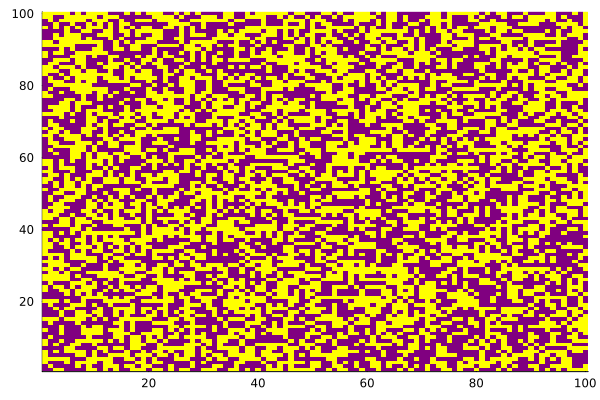

In [55]:
using Plots

heatmap(lattice_rand, colorbar=false, color=[:purple, :yellow], clims=(0,1))

### La energía del sistema

La energía de un sistema en el modelo de Ising está dada por el **hamiltoniano**.
$$\mathcal H(\sigma) = -\sum_{\langle i, j\rangle} J_{ij}\sigma_i\sigma_j- \mu\sum_{i=1}^N B_i\sigma_i$$
Donde la notación $\langle i, j\rangle$ indica que la primera suma se realiza únicamente sobre los pares de spins vecinos. $J_{ij}$ representa un factor de acoplamiento entre los spins $i$ y $j$, $B_i$ representa la magnitud del campo magnético externo, y $\mu$ es el momento magnético.
A continuación consideraremos que $J_{ij}$ es constante, es decir, no depende del par $i,j$, y que no hay campo externo $B$. Además, como el hamiltoniano representa la energía del sistema escribiremos $E=\mathcal H$.

En ausencia de campo externo y $J_{ij}$ constante tenemos
$$\mathcal H(\sigma) = -J_{ij}\sum_{\langle i, j\rangle} \sigma_i\sigma_j$$

En un sistema con finitos spins, es necesrio considerar condiciones de borde. En este caso consideraremos condiciones de borde periódicas, es decir, aquellos spins que no poseen vecino en alguna dirección, interactúan en ese dirección con el spin del otro extremo. En este sentido, podemos pensar el sistema de lattice conectado entre sí en forma de toro.

Una primera aproximación para calcular el hamiltoniano de un sistema sería considerar explícitamente las condiciones de borde en el ciclo `for`.

In [56]:
function get_energy(lattice, J=1)
    N, M = size(lattice)
    energy = 0.0

    @inbounds @simd for i in 1:N
        for j in 1:M 
            neighbors = 0

            #vecino de arriba
            if i > 1
                neighbors += lattice[i-1, j]
            elseif i == 1
                neighbors += lattice[N, j]
            end
            #vecino de abajo
            if i < N
                neighbors += lattice[i+1, j]
            elseif i == N
                neighbors += lattice[1, j]
            end
            #vecino de la izquierda
            if j > 1
                neighbors += lattice[i, j-1]
            elseif j == 1
                neighbors += lattice[i, M]
            end 
            #vecino de la derecha
            if j < M 
                neighbors += lattice[i, j+1]
            elseif j == M
                neighbors += lattice[i, 1]
            end

            energy -= J * lattice[i, j] * neighbors
        end
    end

    return energy / 2.0 # se divide por 2 porque contamos dos veces cada interacción
end

get_energy (generic function with 2 methods)

Otra aproximación a formular un algoritmo para esta función sería usar convolución con un kernel
$$K = \begin{bmatrix} 0 & 1 & 0\\ 1 & 0 & 1\\ 0 & 1 & 1\end{bmatrix}$$
para obtener las interacciones entre vecinos. Así si la lattice es $\mathcal L$ y el kernel es $K$, ejecutar
$$(\mathcal L* K)$$
nos otorga la suma de los spins vecinos, es decir $(\mathcal L * K)$ es un arreglo bidimensional donde en cada posición está la suma de los vecinos del spin que estaba en esa posición. Luego para obtener las iteracciones simlemente habría que multiplicar cada spin por la suma de sus vecinos, y luego multiplicar por $-J$. Así la alternativa con convolución se ve como sigue.

In [57]:
using ImageFiltering

function get_energy_conv(lattice, J=1)
    kernel = centered([0 1 0; #kernel con centrado en la posición 2, 2
                       1 0 1;
                       0 1 0])

    neighbors = imfilter(lattice, kernel, "circular") # Suma de vecinos / convolución
    energy = -J * sum(lattice .* neighbors) / 2.0 # -J*spin*vecinos /2
    return energy
end

get_energy_conv (generic function with 2 methods)

Una tercera opción utiliza aritmética modular para calcular la energía. Cuando sumamos por ejemplo el vecino de arriba, en vez de sumar `lattice[i-1, j]` dependiendo de si estamos en el borde o no, podemos sumar `lattice[mod1(i-1, N), j] ` siempre. Veamos por casos por qué esto funciona.

Si estamos en el caso en que el spin actual es un spin del interior y queremos sumar el vecino de arriba, nos gustaría que la fila sea exactamente $i-1$, esto funciona ya que $i-1\bmod N$ será siempre igual a $i-1$. Esto es análogo para cualquier vecino interior.

Ahora, si estamos en el borde superior y queremos sumar el vecino de arriba, tenemos $i=1$, entonces $i-1\bmod N = 0\bmod N=0$, que no es lo que queremos, sin embargo la función `mod1(x, y)` de julia siempre entrega un valor en $(0, y]$, por lo que en este caso la función entrega `mod1(0, N)=N`, que es justamente lo que queríamos para la condición periódica con los índice entre $1$ y $N$

Por último, en el caso borde en que estamos en el borde inferior del arreglo y queremos sumar el vecino de abajo, tenemos $i=N$, entonces $i+1\bmod N=N+1\bmod N=1$ que es justamente lo que queríamos y lo que entrega `mod1(i+1, N)`.

Los casos de vecinos en otras direcciones son análogos.

In [58]:
function get_energy_mod(lattice, J=1)
    N, M = size(lattice)
    energy = 0.0

    @inbounds for i in 1:N
        for j in 1:M
            neighbors = lattice[mod1(i - 1, N), j] + 
                        lattice[mod1(i + 1, N), j] + 
                        lattice[i, mod1(j - 1, M)] + 
                        lattice[i, mod1(j + 1, M)]

            energy -= J * lattice[i, j] * neighbors
        end
    end

    return energy / 2.0
end

get_energy_mod (generic function with 2 methods)

### Tests

A continuación haremos algunos benchmarks para medir la eficiencia práctica de cada una de estas versiones de la función `get_energy`.

In [59]:
using BenchmarkTools
using Random

n = 100

init_random = rand(n, n)
lattice_rand = zeros(Int, n, n)
lattice_rand[init_random .>=0.5] .= 1
lattice_rand[init_random .< 0.5] .= -1
lattice_rand;

In [60]:
println(get_energy(lattice_rand))
println(get_energy_conv(lattice_rand))
println(get_energy_mod(lattice_rand))

-8.0
-8.0
-8.0


In [61]:
println("-- Benchmark get_energy versión iterativa --")
@btime get_energy($lattice_rand)
println("-- Benchmark get_energy versión con convolución --")
@btime get_energy_conv($lattice_rand)
println("-- Benchmark get_energy versión modular --")
@btime get_energy_mod($lattice_rand)

-- Benchmark get_energy versión iterativa --
  12.600 μs (0 allocations: 0 bytes)
-- Benchmark get_energy versión con convolución --
  83.300 μs (16 allocations: 239.82 KiB)
-- Benchmark get_energy versión modular --
  68.500 μs (0 allocations: 0 bytes)


-8.0

Según estos experimentos la versión más eficiente en términos de espacio y tiempo es la versión explícita original. La versión con convolución por otro lado es la menos eficiente en términos de tiempo, además en terminos de memoria también es ineficiente ya que debe almacenar arreglos completos antes de retornar. Por último la versión con aritmética modular es una versión intermedia en términos de eficiencia.

In [62]:
@benchmark get_energy($lattice_rand)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  12.600 μs … 147.700 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     12.700 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   13.239 μs ±   3.906 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █▇▃                ▃▁                                        ▁
  ███▆▅▃▄▅▆▄▆▅▅▆▆▄▅▆▄███▇▅▃▅▅▄▅▅▄▅▁▁▅▅▄▅▃▁▃▁▃▅▁▁▅▆▄▆▆▄▆▆▃▆▆▃▅▃ █
  12.6 μs       Histogram: log(frequency) by time      22.6 μs <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [63]:
@benchmark get_energy_conv($lattice_rand)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   82.700 μs …  2.235 ms  ┊ GC (min … max): 0.00% … 94.95%
 Time  (median):      87.400 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   101.767 μs ± 89.331 μs  ┊ GC (mean ± σ):  8.89% ±  9.51%

  █▃▂▁▁▂▁                                                      ▁
  █████████▆▇▆▆▄▅▃▁▁▃▁▁▁▁▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▄▄▆▅ █
  82.7 μs       Histogram: log(frequency) by time       710 μs <

 Memory estimate: 239.82 KiB, allocs estimate: 16.

In [64]:
@benchmark get_energy_mod($lattice_rand)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  68.500 μs … 171.100 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     68.600 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   70.742 μs ±   6.750 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █ ▁▁▆  ▁                       ▁                             ▁
  █▇████████▇▆▇▆▅▆▅▆▆▆▆▅▅▆▅▅▆▅▅▄▅█▅▃▅▄▆▅▅▄▅▃▃▂▄▄▄▄▄▃▄▄▅▄▅▅▆▅▆▆ █
  68.5 μs       Histogram: log(frequency) by time       102 μs <

 Memory estimate: 0 bytes, allocs estimate: 0.